# AIFS–ERA5 RMSE Analysis (Reproducible Workflow)

## ⚠️ Important note on data availability

This notebook compares **AIFS operational forecasts** with **ERA5 reanalysis** at matching valid times.

Due to the nature of the data sources:

- **ERA5 reanalysis** is available only up to ~5 days before the current date.
- **AIFS forecasts** are available only for the most recent ~4 days.
- RMSE computation requires **overlapping valid times** between the two datasets.

### What this means in practice

- A fresh run of this notebook may initially produce **no matching AIFS–ERA5 pairs**.
- This is expected behavior and does not indicate an error in the pipeline.
- Matching periods exist only once:
  - AIFS forecasts have been downloaded for several consecutive days, and
  - ERA5 has become available for those same dates.

### How matching data are normally obtained

- AIFS and ERA5 data are downloaded daily using the scheduled scripts in data_access/scripts/schedule/


### Options for the reviewer

- If matching data already exist in `data/`, the notebook will detect and use them automatically.
- If no matches are found, the notebook will exit gracefully with a diagnostic message.
- Reproducing the full pipeline from scratch requires CDS/MARS access and several days of data accumulation.

This behavior is intentional and reflects real-world operational constraints.



## 1. Setup and Configuration

In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import rasterio
from rasterio.transform import rowcol
from matplotlib.colors import ListedColormap

# Paths
REPO_ROOT = Path.cwd().resolve().parent
SCRIPTS_DIR = REPO_ROOT / 'data_access' / 'scripts'
AIFS_ROOT = REPO_ROOT / 'data' / 'aifs' / 'raw'
ERA5_ARCHIVE = REPO_ROOT / 'data' / 'era5' / 'archive' / 'real'
RMSE_OUT = REPO_ROOT / 'data' / 'rmse_outputs'
KOPPEN_RASTER = REPO_ROOT / 'data' / 'static' / 'koppen_geiger_0p1.tif'
OROG_RASTER = REPO_ROOT / 'data' / 'static' / 'era5_orography.nc'

# Create output directories
RMSE_OUT.mkdir(parents=True, exist_ok=True)
INDEX_DIR = RMSE_OUT / 'cfgrib_index'
INDEX_DIR.mkdir(parents=True, exist_ok=True)

# Constants
VARIABLES = ['2t', 't500']
EUROPE_EXTENT = (-5, 25, 43, 58)  # (lon_min, lon_max, lat_min, lat_max)

print(f"✓ Paths configured:")
print(f"  REPO_ROOT: {REPO_ROOT}")
print(f"  AIFS_ROOT: {AIFS_ROOT}")
print(f"  ERA5_ARCHIVE: {ERA5_ARCHIVE}")
print(f"  RMSE_OUT: {RMSE_OUT}")

✓ Paths configured:
  REPO_ROOT: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing
  AIFS_ROOT: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/data/aifs/raw
  ERA5_ARCHIVE: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/data/era5/archive/real
  RMSE_OUT: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/data/rmse_outputs


In [3]:
# Import RMSE pipeline functions

mods_to_remove = [m for m in sys.modules.keys() if 'aifs_era5_rmse' in m or 'compute_rmse_outputs' in m]
for m in mods_to_remove:
    del sys.modules[m]

# Add SCRIPTS_DIR to path
if str(SCRIPTS_DIR) in sys.path:
    sys.path.remove(str(SCRIPTS_DIR))
sys.path.insert(0, str(SCRIPTS_DIR))

from aifs_era5_rmse import (
    index_aifs_files,
    index_era5_archive,
    filter_era5_index_by_product,
    filter_aifs_index_by_levtype,
    pair_aifs_with_era5_for_variable,
    compute_pair_rmse,
    EUROPE_BBOX,
    VARIABLE_CONFIG,
)

from compute_rmse_outputs import compute_rmse_outputs

In [14]:
# ...existing code...
import runpy
import sys

print("Running data access scripts...\n")
for script in [
    SCRIPTS_DIR / 'download_aifs_daily.py',
    SCRIPTS_DIR / 'era5_download_only.py',
]:
    try:
        print(f"  Running {script.name}...")
        old_argv = sys.argv.copy()
        sys.argv = [str(script)]  # clear kernel args so argparse in script sees only intended args
        runpy.run_path(str(script), run_name='__main__')
    except SystemExit as e:
        print(f"    (exited with code {e.code})")
    except Exception as e:
        print(f"    Error: {e}")
    finally:
        sys.argv = old_argv
print("\n✓ Download scripts completed")
# ...existing code...

2026-01-27 14:14:58,738 - __main__ - INFO - ============================================================
2026-01-27 14:14:58,739 - __main__ - INFO - Starting AIFS data download
2026-01-27 14:14:58,740 - __main__ - INFO - ============================================================
2026-01-27 14:14:58,742 - __main__ - INFO - Output directory: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/data/aifs/raw
2026-01-27 14:14:58,742 - __main__ - INFO - Dates to download: ['2026-01-24', '2026-01-25', '2026-01-26', '2026-01-27']
2026-01-27 14:14:58,742 - __main__ - INFO - Skipping existing file: aifs-single_20260124_00_sfc_2t-msl-10u-10v_step006_0p25.grib2
2026-01-27 14:14:58,743 - __main__ - INFO - Skipping existing file: aifs-single_20260124_00_sfc_2t-msl-10u-10v_step012_0p25.grib2
2026-01-27 14:14:58,743 - __main__ - INFO - Skipping existing file: aifs-single_20260124_00_sfc_2t-msl-10u-10v_step018_0p25.grib2
2026-01-27 14:14:58,743 - __main__ - INFO - Skipping exi

2026-01-27 14:14:58,745 - __main__ - INFO - Skipping existing file: aifs-single_20260124_12_sfc_2t-msl-10u-10v_step036_0p25.grib2
2026-01-27 14:14:58,746 - __main__ - INFO - Skipping existing file: aifs-single_20260124_12_sfc_2t-msl-10u-10v_step048_0p25.grib2
2026-01-27 14:14:58,746 - __main__ - INFO - Skipping existing file: aifs-single_20260125_00_sfc_2t-msl-10u-10v_step006_0p25.grib2
2026-01-27 14:14:58,747 - __main__ - INFO - Skipping existing file: aifs-single_20260125_00_sfc_2t-msl-10u-10v_step012_0p25.grib2
2026-01-27 14:14:58,747 - __main__ - INFO - Skipping existing file: aifs-single_20260125_00_sfc_2t-msl-10u-10v_step018_0p25.grib2
2026-01-27 14:14:58,748 - __main__ - INFO - Skipping existing file: aifs-single_20260125_00_sfc_2t-msl-10u-10v_step024_0p25.grib2
2026-01-27 14:14:58,748 - __main__ - INFO - Skipping existing file: aifs-single_20260125_00_sfc_2t-msl-10u-10v_step036_0p25.grib2
2026-01-27 14:14:58,748 - __main__ - INFO - Skipping existing file: aifs-single_20260125_0

Running data access scripts...

  Running download_aifs_daily.py...


2026-01-27 14:15:00,288 - __main__ - ERROR - Failed to download SFC 2026-01-27 step 6h: 404 Client Error: Not Found for url: https://data.ecmwf.int/forecasts/20260127/12z/aifs-single/0p25/oper/20260127120000-6h-oper-fc.index
2026-01-27 14:15:00,291 - __main__ - INFO - Requesting PL 500hPa 2026-01-27 12Z step   6h -> aifs-single_20260127_12_pl_t_500hPa_step006_0p25.grib2
2026-01-27 14:15:02,195 - __main__ - ERROR - Failed to download PL 500hPa 2026-01-27 step 6h: 404 Client Error: Not Found for url: https://data.ecmwf.int/forecasts/20260127/12z/aifs-single/0p25/oper/20260127120000-6h-oper-fc.index
2026-01-27 14:15:02,198 - __main__ - INFO - Requesting SFC 2026-01-27 12Z step  12h -> aifs-single_20260127_12_sfc_2t-msl-10u-10v_step012_0p25.grib2
2026-01-27 14:15:03,280 - __main__ - ERROR - Failed to download SFC 2026-01-27 step 12h: 404 Client Error: Not Found for url: https://data.ecmwf.int/forecasts/20260127/12z/aifs-single/0p25/oper/20260127120000-12h-oper-fc.index
2026-01-27 14:15:03,

    (exited with code 1)
  Running era5_download_only.py...
    (exited with code 1)

✓ Download scripts completed


## 2. Index Data Sources

In [15]:
print("Indexing AIFS and ERA5 files...\n")

# Index AIFS
aifs_index = index_aifs_files(AIFS_ROOT)
print(f"AIFS Index:")
print(f"  Total files: {len(aifs_index)}")
print(f"  Date range: {aifs_index['valid_dt'].min()} to {aifs_index['valid_dt'].max()}")

# Extract lead times from filenames (e.g., step006, step012)
if 'path' in aifs_index.columns:
    steps = set()
    for fpath in aifs_index['path']:
        if 'step' in fpath:
            import re
            match = re.search(r'step(\d+)', fpath)
            if match:
                steps.add(int(match.group(1)))
    if steps:
        print(f"  Lead times (hours): {sorted(steps)}")

# Index ERA5
era5_all = index_era5_archive(ERA5_ARCHIVE, variable=None)
print(f"\nERA5 Index:")
print(f"  Total files: {len(era5_all)}")
if len(era5_all) > 0:
    print(f"  Date range: {era5_all['date'].min()} to {era5_all['date'].max()}")
    print(f"  Product tags: {list(era5_all['product_tag'].unique())}")
    for tag in sorted(era5_all['product_tag'].unique()):
        subset = era5_all[era5_all['product_tag'] == tag]
        print(f"    {tag}: {len(subset)} files")
        print("Pairing AIFS with ERA5...\n")


Indexing AIFS and ERA5 files...

AIFS Index:
  Total files: 185
  Date range: 2026-01-19 06:00:00 to 2026-01-28 12:00:00
  Lead times (hours): [6, 12, 18, 24, 36, 48]

ERA5 Index:
  Total files: 24
  Date range: 2024-12-01 to 2026-01-22
  Product tags: ['unknown', 't2m', 't_pl500']
    t2m: 15 files
Pairing AIFS with ERA5...

    t_pl500: 4 files
Pairing AIFS with ERA5...

    unknown: 5 files
Pairing AIFS with ERA5...



## 3. Pair AIFS with ERA5

In [16]:
pairs_dict = {}

for var in VARIABLES:
    print(f"{var}:")
    
    # Get config
    config = VARIABLE_CONFIG[var]
    aifs_levtype = "sfc" if config["aifs"]["filter_by_keys"]["typeOfLevel"] == "heightAboveGround" else "pl"
    
    # Determine ERA5 product tag
    if var == "2t":
        era5_tag = "t2m"
    elif var == "t500":
        era5_tag = "t_pl500"
    else:
        era5_tag = config["era5"]["var"]
    
    # Filter indices
    aifs_filt = filter_aifs_index_by_levtype(aifs_index, aifs_levtype)
    era5_filt = filter_era5_index_by_product(era5_all, era5_tag)
    
    print(f"  AIFS {aifs_levtype}: {len(aifs_filt)} files")
    print(f"  ERA5 {era5_tag}: {len(era5_filt)} files")
    
    if len(era5_filt) == 0:
        print(f"  ⚠️  No ERA5 files for {var}, skipping")
        continue
    
    # Pair
    pairs = pair_aifs_with_era5_for_variable(aifs_filt, era5_filt, var)
    pairs_dict[var] = pairs
    
    # Status breakdown
    status_counts = pairs['status'].value_counts().to_dict()
    ok_pairs = len(pairs[pairs['status'] == 'ok'])
    print(f"  Total pairs: {len(pairs)}")
    print(f"  OK pairs: {ok_pairs}")
    print(f"  Status breakdown: {status_counts}")
    
    # Save manifest
    pairs.to_csv(RMSE_OUT / f'pairs_manifest_{var}.csv', index=False)
    print(f"  ✓ Saved pairs_manifest_{var}.csv\n")

2t:
  AIFS sfc: 94 files
  ERA5 t2m: 15 files
  Total pairs: 94
  OK pairs: 29
  Status breakdown: {'missing_era5': 60, 'ok': 29, 'time_not_found': 5}
  ✓ Saved pairs_manifest_2t.csv

t500:
  AIFS pl: 91 files
  ERA5 t_pl500: 4 files
  Total pairs: 91
  OK pairs: 27
  Status breakdown: {'missing_era5': 59, 'ok': 27, 'time_not_found': 5}
  ✓ Saved pairs_manifest_t500.csv



## 4. Compute RMSE Outputs

In [17]:
    # Compute spatial and temporal aggregations
print("Computing RMSE outputs (spatial maps + aggregations)...\n")

pairs_2t = pairs_dict.get('2t')
pairs_t500 = pairs_dict.get('t500')

compute_rmse_outputs(
    pairs_2t=pairs_2t,
    pairs_t500=pairs_t500,
    compute_rmse_for_pairs_func=compute_pair_rmse,
    index_dir=INDEX_DIR,
    output_dir=RMSE_OUT,
    bbox=EUROPE_BBOX,
    variables=VARIABLES,
)

print("\n✓ RMSE outputs computation completed")

2026-01-27 14:17:44,924 - compute_rmse_outputs - INFO - 
2026-01-27 14:17:44,925 - compute_rmse_outputs - INFO - Processing 2t: 29 OK pairs
2026-01-27 14:17:44,925 - compute_rmse_outputs - INFO - ============================================================
2026-01-27 14:17:44,926 - compute_rmse_outputs - INFO - Computing per-pair squared-error grids...
2026-01-27 14:17:44,974 - compute_rmse_outputs - INFO -   ✓ Pair 1/29: valid_dt=2026-01-19 06:00:00, step=6h, se_shape=(49, 81)
2026-01-27 14:17:45,019 - compute_rmse_outputs - INFO -   ✓ Pair 2/29: valid_dt=2026-01-19 12:00:00, step=12h, se_shape=(49, 81)
2026-01-27 14:17:45,051 - compute_rmse_outputs - INFO -   ✓ Pair 3/29: valid_dt=2026-01-19 18:00:00, step=18h, se_shape=(49, 81)
2026-01-27 14:17:45,095 - compute_rmse_outputs - INFO -   ✓ Pair 4/29: valid_dt=2026-01-20 00:00:00, step=24h, se_shape=(49, 81)


Computing RMSE outputs (spatial maps + aggregations)...



2026-01-27 14:17:45,134 - compute_rmse_outputs - INFO -   ✓ Pair 5/29: valid_dt=2026-01-20 12:00:00, step=36h, se_shape=(49, 81)
2026-01-27 14:17:45,179 - compute_rmse_outputs - INFO -   ✓ Pair 6/29: valid_dt=2026-01-21 00:00:00, step=48h, se_shape=(49, 81)
2026-01-27 14:17:45,210 - compute_rmse_outputs - INFO -   ✓ Pair 7/29: valid_dt=2026-01-19 18:00:00, step=6h, se_shape=(49, 81)
2026-01-27 14:17:45,241 - compute_rmse_outputs - INFO -   ✓ Pair 8/29: valid_dt=2026-01-20 00:00:00, step=12h, se_shape=(49, 81)
2026-01-27 14:17:45,272 - compute_rmse_outputs - INFO -   ✓ Pair 9/29: valid_dt=2026-01-20 06:00:00, step=18h, se_shape=(49, 81)
2026-01-27 14:17:45,304 - compute_rmse_outputs - INFO -   ✓ Pair 10/29: valid_dt=2026-01-20 12:00:00, step=24h, se_shape=(49, 81)
2026-01-27 14:17:45,335 - compute_rmse_outputs - INFO -   ✓ Pair 11/29: valid_dt=2026-01-21 00:00:00, step=36h, se_shape=(49, 81)
2026-01-27 14:17:45,377 - compute_rmse_outputs - INFO -   ✓ Pair 12/29: valid_dt=2026-01-21 12:0


✓ RMSE outputs computation completed


## 5. Load and Validate Precomputed Results

In [24]:
print("Loading and validating RMSE outputs...\n")
# Data loaders (eager-load then close to avoid netCDF handle issues)
def _open_rmse(path: Path) -> xr.Dataset:
    ds = xr.open_dataset(path)
    ds.load()
    ds.close()
    return ds


# Data loaders
def load_rmse_by_step(var):
    path = RMSE_OUT / f'rmse_by_step_{var}.nc'
    return xr.open_dataset(path)

def load_rmse_by_day(var):
    path = RMSE_OUT / f'rmse_by_day_{var}.nc'
    return xr.open_dataset(path)

def load_rmse_by_hour(var):
    path = RMSE_OUT / f'rmse_by_hour_{var}.nc'
    return xr.open_dataset(path)

# Validate outputs for each variable
outputs_summary = {}

for var in VARIABLES:
    print(f"{var}:")
    results = {}
    
    for agg_type, loader in [
        ('by_step', load_rmse_by_step),
        ('by_day', load_rmse_by_day),
        ('by_hour', load_rmse_by_hour),
    ]:
        try:
            ds = loader(var)
            results[agg_type] = ds
            
            rmse = ds['rmse']
            dims_str = f"{list(rmse.dims)}"
            shape_str = f"{rmse.shape}"
            n_pairs = ds.attrs.get('n_pairs', 'N/A')
            
            print(f"  {agg_type}: dims={dims_str}, shape={shape_str}, n_pairs={n_pairs}")
        except FileNotFoundError:
            print(f"  {agg_type}: ⚠️  File not found")
        except Exception as e:
            print(f"  {agg_type}: ✗ Error - {e}")
    
    outputs_summary[var] = results
    print()

Loading and validating RMSE outputs...

2t:
  by_step: dims=['step', 'latitude', 'longitude'], shape=(6, 49, 81), n_pairs=29
  by_day: dims=['date', 'latitude', 'longitude'], shape=(4, 49, 81), n_pairs=29
  by_hour: dims=['hour', 'latitude', 'longitude'], shape=(4, 49, 81), n_pairs=29

t500:
  by_step: dims=['step', 'latitude', 'longitude'], shape=(6, 49, 81), n_pairs=27
  by_day: dims=['date', 'latitude', 'longitude'], shape=(4, 49, 81), n_pairs=27
  by_hour: dims=['hour', 'latitude', 'longitude'], shape=(4, 49, 81), n_pairs=27



In [25]:
    # Detailed sanity check
print("Detailed output validation:\n")

for var in VARIABLES:
    print(f"\n{var}:")
    
    try:
        ds_step = load_rmse_by_step(var)
        rmse = ds_step['rmse']
        
        print(f"  RMSE by step:")
        print(f"    Min: {float(rmse.min()):.4f} K")
        print(f"    Max: {float(rmse.max()):.4f} K")
        print(f"    Mean: {float(rmse.mean()):.4f} K")
        print(f"    NaN fraction: {float(np.isnan(rmse).sum()) / rmse.size:.1%}")
        print(f"    Steps available: {list(ds_step.coords['step'].values)}")
    except Exception as e:
        print(f"  Error: {e}")

Detailed output validation:


2t:
  RMSE by step:
    Min: 0.0224 K
    Max: 9.2102 K
    Mean: 1.0256 K
    NaN fraction: 0.0%
    Steps available: [np.int64(6), np.int64(12), np.int64(18), np.int64(24), np.int64(36), np.int64(48)]

t500:
  RMSE by step:
    Min: 0.0120 K
    Max: 1.6687 K
    Mean: 0.3265 K
    NaN fraction: 0.0%
    Steps available: [np.int64(6), np.int64(12), np.int64(18), np.int64(24), np.int64(36), np.int64(48)]


## 6. Visualization Setup (Plotting Functions)

In [26]:
# Helper plotting functions

def setup_map_ax(title="", extent=EUROPE_EXTENT):
    """Create cartographic axes over Europe."""
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.5)
    ax.add_feature(ccrs.cartopy.feature.BORDERS, linewidth=0.5)
    
    gl = ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.3, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold')
    
    return fig, ax

def add_koppen_background(ax, koppen_path):
    """Overlay Köppen–Geiger climate zones (skipped if file unavailable)."""
    if not koppen_path.exists():
        return
    
    try:
        src = rasterio.open(str(koppen_path))
        data = src.read(1)
        transform = src.transform
        src.close()
        
        koppen_lookup = {
            1: 'Af', 2: 'Am', 3: 'Aw', 4: 'BWh', 5: 'BWk', 6: 'BSh', 7: 'BSk',
            8: 'Csa', 9: 'Csb', 10: 'Csc', 11: 'Cwa', 12: 'Cwb', 13: 'Cwc',
            14: 'Cfa', 15: 'Cfb', 16: 'Cfc', 17: 'Dsa', 18: 'Dsb', 19: 'Dsc', 20: 'Dsd',
            21: 'Dwa', 22: 'Dwb', 23: 'Dwc', 24: 'Dwd', 25: 'Dfa', 26: 'Dfb',
            27: 'Dfc', 28: 'Dfd', 29: 'ET', 30: 'EF'
        }
        
        lon_min, lon_max, lat_min, lat_max = EUROPE_EXTENT
        row_min, col_min = rowcol(transform, lon_min, lat_max)
        row_max, col_max = rowcol(transform, lon_max, lat_min)
        row_min, row_max = sorted([row_min, row_max])
        col_min, col_max = sorted([col_min, col_max])
        data_crop = data[row_min:row_max+1, col_min:col_max+1]
        
        present_codes = sorted({int(c) for c in np.unique(data_crop) if int(c) in koppen_lookup})
        if len(present_codes) > 0:
            labels = [koppen_lookup[c] for c in present_codes]
            colors = plt.cm.tab20.colors
            cmap = ListedColormap([colors[i % len(colors)] for i in range(len(present_codes))])
            code_to_index = {code: i for i, code in enumerate(present_codes)}
            indexed = np.vectorize(lambda v: code_to_index.get(int(v), np.nan))(data_crop)
            
            ax.imshow(
                indexed,
                origin='upper',
                extent=[lon_min, lon_max, lat_min, lat_max],
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                alpha=0.4,
                zorder=1,
            )
    except Exception as e:
        # Silently skip Köppen background on any error
        pass

def add_orography_overlay(ax, orog_path):
    """Overlay ERA5 orography in grayscale."""
    if not orog_path.exists():
        return
    
    try:
        ds = xr.open_dataset(orog_path)
        if 'z' in ds:
            z = ds['z'] / 9.80665  # geopotential -> meters
            
            # Handle multi-dimensional data by squeezing extra dimensions
            if z.ndim > 2:
                z = z.squeeze()
            
            # Select extent
            z_crop = z.sel(
                longitude=slice(EUROPE_EXTENT[0], EUROPE_EXTENT[1]),
                latitude=slice(EUROPE_EXTENT[3], EUROPE_EXTENT[2])
            )
            
            # Final squeeze in case selection created singleton dims
            z_values = np.squeeze(z_crop.values)
            
            if z_values.ndim == 2:
                ax.imshow(
                    z_values,
                    origin='upper',
                    extent=EUROPE_EXTENT,
                    transform=ccrs.PlateCarree(),
                    cmap='Greys',
                    alpha=0.15,
                    zorder=2,
                )
    except Exception as e:
        # Silently skip orography on any error
        pass

print("✓ Plotting functions defined")

✓ Plotting functions defined


In [27]:
# Koppen & Orography loaders + preload (run once)
from pathlib import Path
import rasterio
from rasterio.windows import from_bounds
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


def load_koppen_crop(koppen_path, extent):
    """Return (indexed_image, cmap, extent_box) or (None, None, None) on error.
    extent = (lon_min, lon_max, lat_min, lat_max)
    """
    if not koppen_path.exists():
        return None, None, None
    lon_min, lon_max, lat_min, lat_max = extent
    try:
        src = rasterio.open(str(koppen_path))
        arr = src.read(1)
        transform = src.transform
        window = from_bounds(lon_min, lat_min, lon_max, lat_max, transform)
        r0, c0 = int(window.row_off), int(window.col_off)
        r1 = r0 + int(window.height)
        c1 = c0 + int(window.width)
        crop = arr[r0:r1, c0:c1]
        src.close()

        koppen_lookup = {
            1: 'Af', 2: 'Am', 3: 'Aw', 4: 'BWh', 5: 'BWk', 6: 'BSh', 7: 'BSk',
            8: 'Csa', 9: 'Csb', 10: 'Csc', 11: 'Cwa', 12: 'Cwb', 13: 'Cwc',
            14: 'Cfa', 15: 'Cfb', 16: 'Cfc', 17: 'Dsa', 18: 'Dsb', 19: 'Dsc', 20: 'Dsd',
            21: 'Dwa', 22: 'Dwb', 23: 'Dwc', 24: 'Dwd', 25: 'Dfa', 26: 'Dfb',
            27: 'Dfc', 28: 'Dfd', 29: 'ET', 30: 'EF'
        }

        # Use full mapping for consistent colors across runs
        full_codes = sorted(koppen_lookup.keys())
        code_to_index = {code: i for i, code in enumerate(full_codes)}
        indexed = np.full_like(crop, np.nan, dtype=float)
        for code in full_codes:
            indexed[crop == code] = code_to_index[code]

        cmap = plt.cm.get_cmap('tab20', len(full_codes))
        extent_box = [lon_min, lon_max, lat_min, lat_max]
        return indexed, cmap, extent_box

    except Exception as e:
        print("Koppen load error:", e)
        return None, None, None


def load_orography_crop(orog_path, extent):
    """Return (z_values_2d, vmin, vmax) or (None, None, None) on error."""
    if not orog_path.exists():
        return None, None, None
    try:
        ds = xr.open_dataset(orog_path)
        var = 'z' if 'z' in ds else list(ds.data_vars)[0]
        z = ds[var]
        if var == 'z':
            z = z / 9.80665
        if z.ndim > 2:
            z = z.squeeze()
        lon_min, lon_max, lat_min, lat_max = extent
        z_crop = z.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_max, lat_min))
        z_values = np.squeeze(z_crop.values)
        if z_values.ndim != 2:
            return None, None, None
        return z_values, np.nanmin(z_values), np.nanmax(z_values)
    except Exception as e:
        print("Orography load error:", e)
        return None, None, None


# Preload using notebook globals (if present)
try:
    koppen_image, koppen_cmap, koppen_extent = load_koppen_crop(KOPPEN_RASTER, EUROPE_EXTENT)
except Exception:
    koppen_image, koppen_cmap, koppen_extent = (None, None, None)

try:
    orog_image, orog_vmin, orog_vmax = load_orography_crop(OROG_RASTER, EUROPE_EXTENT)
except Exception:
    orog_image, orog_vmin, orog_vmax = (None, None, None)

print(f"koppen_image: {None if koppen_image is None else koppen_image.shape}, orog_image: {None if orog_image is None else orog_image.shape}")


koppen_image: None, orog_image: (61, 121)


## 7. RMSE Map Visualization (Ready for Your Plots)

The cells below are templates. Add your plot code here.

✓ Orography loaded: (61, 121)

  Plotting 2t...
  Plotting t500...
    Load: 0.01s
    Coarsen: 0.00s
    Data shape: (12, 20), extent: [np.float64(0.375), np.float64(19.375), np.float64(44.375), np.float64(55.375)]
    RMSE plot: 0.00s
    Dots: 0.00s
    t500 total: 0.03s

  Save: 0.12s


Traceback (most recent call last):
  File "/Users/yeganehkhabbazian/miniforge3/envs/aifs/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 219, in _acquire_with_cache_info
    file = self._cache[self._key]
           ~~~~~~~~~~~^^^^^^^^^^^
  File "/Users/yeganehkhabbazian/miniforge3/envs/aifs/lib/python3.11/site-packages/xarray/backends/lru_cache.py", line 56, in __getitem__
    value = self._cache[key]
            ~~~~~~~~~~~^^^^^
KeyError: [<class 'netCDF4._netCDF4.Dataset'>, ('/Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/data/rmse_outputs/rmse_by_step_2t.nc',), 'r', (('clobber', True), ('diskless', False), ('format', 'NETCDF4'), ('persist', False)), 'e586ddce-3636-478e-af19-fd234e559489']

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/var/folders/gy/qtrvr3ms3yb08db3q74z72300000gn/T/ipykernel_24561/2249155577.py", line 98, in <module>
    ds_step = load_rmse_by_step(var

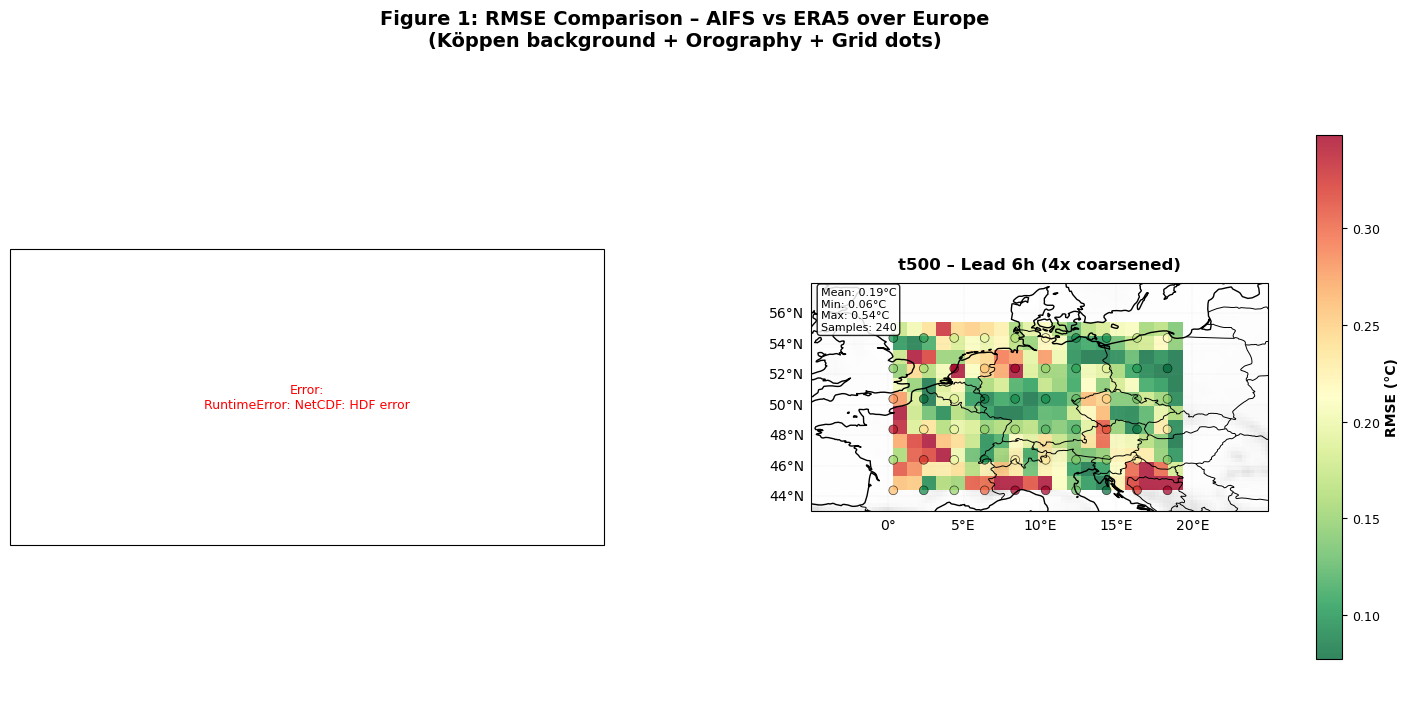


✓ Figure 1 complete in 0.25s
✓ Saved to: /tmp/rmse_maps_corrected.png


In [28]:
# Figure 1: RMSE Maps over Europe (IMPROVED VISUALIZATION)
# - Prominent Köppen background with distinct colors
# - Visible RMSE grid dots with color mapping
# - Proper coordinate handling and error checking

import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
import warnings
import time
from rasterio.windows import from_bounds
warnings.filterwarnings('ignore')

try:
    t_start = time.time()
    
    # ========== PRELOAD BACKGROUNDS ONCE ==========
    lon_min, lon_max, lat_min, lat_max = EUROPE_EXTENT  # (-5, 25, 43, 58)
    
    # Load and crop Köppen once
    koppen_image = None
    koppen_cmap = None
    try:
        if KOPPEN_RASTER.exists():
            src = rasterio.open(str(KOPPEN_RASTER))
            koppen_full = src.read(1)
            koppen_transform = src.transform
            
            # Fast rasterio window indexing
            window = from_bounds(lon_min, lat_min, lon_max, lat_max, koppen_transform)
            row_min, col_min = int(window.row_off), int(window.col_off)
            row_max = row_min + int(window.height)
            col_max = col_min + int(window.width)
            koppen_crop = koppen_full[row_min:row_max, col_min:col_max]
            
            # Build indexed image from crop
            koppen_lookup = {
                1: 'Af', 2: 'Am', 3: 'Aw', 4: 'BWh', 5: 'BWk', 6: 'BSh', 7: 'BSk',
                8: 'Csa', 9: 'Csb', 10: 'Csc', 11: 'Cwa', 12: 'Cwb', 13: 'Cwc',
                14: 'Cfa', 15: 'Cfb', 16: 'Cfc', 17: 'Dsa', 18: 'Dsb', 19: 'Dsc', 20: 'Dsd',
                21: 'Dwa', 22: 'Dwb', 23: 'Dwc', 24: 'Dwd', 25: 'Dfa', 26: 'Dfb',
                27: 'Dfc', 28: 'Dfd', 29: 'ET', 30: 'EF'
            }
            present_codes = sorted({int(c) for c in np.unique(koppen_crop) if c > 0 and c in koppen_lookup})
            
            if len(present_codes) > 0:
                indexed = np.zeros_like(koppen_crop, dtype=float)
                for i, code in enumerate(present_codes):
                    indexed[koppen_crop == code] = i
                indexed[koppen_crop == 0] = np.nan
                koppen_image = indexed
                koppen_cmap = plt.cm.get_cmap('tab20', len(present_codes))
                print(f"✓ Köppen loaded: {koppen_crop.shape}, {len(present_codes)} classes")
            
            src.close()
    except Exception as e:
        print(f"⚠ Köppen background unavailable: {e}")
    
    # Load and crop orography once
    orog_image = None
    try:
        if OROG_RASTER.exists():
            ds_orog = xr.open_dataset(OROG_RASTER)
            if 'z' in ds_orog:
                z = ds_orog['z'] / 9.80665  # geopotential to meters
                if z.ndim > 2:
                    z = z.squeeze()
                
                # Crop to EUROPE_EXTENT
                z_crop = z.sel(
                    longitude=slice(lon_min, lon_max),
                    latitude=slice(lat_max, lat_min)
                )
                z_values = np.squeeze(z_crop.values)
                
                if z_values.ndim == 2:
                    orog_image = z_values
                    orog_vmin, orog_vmax = np.nanmin(z_values), np.nanmax(z_values)
                    print(f"✓ Orography loaded: {z_values.shape}")
    except Exception as e:
        print(f"⚠ Orography unavailable: {e}")
    
    print()
    
    # ========== PLOT LOOP ==========
    fig = plt.figure(figsize=(18, 8))
    gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.3, wspace=0.35)
    
    for plot_idx, var in enumerate(VARIABLES):
        print(f"  Plotting {var}...")
        t_var_start = time.time()
        
        try:
            ax = fig.add_subplot(gs[0, plot_idx], projection=ccrs.PlateCarree())
            ax.set_extent(EUROPE_EXTENT, crs=ccrs.PlateCarree())
            
            # --- Load and crop RMSE to EUROPE_EXTENT ---
            t_load = time.time()
            ds_step = load_rmse_by_step(var)
            rmse = ds_step['rmse']
            rmse_full = rmse.isel(step=0).squeeze()
            step_val = int(rmse_full.step.values)
            
            # Determine coordinate names (try both naming conventions)
            lat_name = None
            lon_name = None
            for dim in rmse_full.dims:
                if dim in ('latitude', 'lat'):
                    lat_name = dim
                elif dim in ('longitude', 'lon'):
                    lon_name = dim
            
            if lat_name is None or lon_name is None:
                print(f"    ✗ Cannot find lat/lon coords. Dims: {rmse_full.dims}")
                ax.text(0.5, 0.5, f'Coordinate error:\nExpected lat/lon, got {rmse_full.dims}',
                       ha='center', va='center', fontsize=10, color='red')
                ax.axis('off')
                continue
            
            # Crop to EUROPE_EXTENT
            rmse_map = rmse_full.sel(
                **{lat_name: slice(lat_max, lat_min), lon_name: slice(lon_min, lon_max)}
            )
            print(f"    Load: {time.time()-t_load:.2f}s")
            
            # --- Sort latitude ascending and coarsen ---
            t_coarse = time.time()
            rmse_map = rmse_map.sortby(lat_name)
            rmse_coarse = rmse_map.coarsen(**{lat_name: 4, lon_name: 4}, boundary='trim').mean()
            print(f"    Coarsen: {time.time()-t_coarse:.2f}s")
            
            # --- Extract coordinates ---
            lats = rmse_coarse[lat_name].values
            lons = rmse_coarse[lon_name].values
            rmse_plot = rmse_coarse.values
            extent_data = [lons.min(), lons.max(), lats.min(), lats.max()]
            
            print(f"    Data shape: {rmse_plot.shape}, extent: {extent_data}")
            
            # --- LAYER 0: Köppen background (PROMINENT) ---
            if koppen_image is not None:
                ax.imshow(koppen_image, origin='upper', extent=[lon_min, lon_max, lat_min, lat_max],
                         cmap=koppen_cmap, transform=ccrs.PlateCarree(),
                         alpha=0.6, zorder=0)
            
            # --- LAYER 1: Orography overlay ---
            if orog_image is not None:
                ax.imshow(orog_image, origin='upper', extent=[lon_min, lon_max, lat_min, lat_max],
                         cmap='Greys', transform=ccrs.PlateCarree(),
                         vmin=orog_vmin, vmax=orog_vmax,
                         alpha=0.25, zorder=1)
            
            # --- LAYER 2: RMSE contours (light background) ---
            valid_mask = ~np.isnan(rmse_plot)
            if valid_mask.any():
                vmin = np.nanpercentile(rmse_plot, 5)
                vmax = np.nanpercentile(rmse_plot, 95)
            else:
                vmin, vmax = 0, 1
            
            t_plot = time.time()
            im = ax.imshow(
                rmse_plot,
                extent=extent_data,
                origin='lower',
                cmap='RdYlGn_r',
                vmin=vmin,
                vmax=vmax,
                transform=ccrs.PlateCarree(),
                interpolation='nearest',
                alpha=0.8,
                zorder=2
            )
            print(f"    RMSE plot: {time.time()-t_plot:.2f}s")
            
            # --- LAYER 5: Grid dots with COLOR MAPPING (VISIBLE) ---
            t_dots = time.time()
            stride = 2  # More frequent dots for visibility
            lon_grid, lat_grid = np.meshgrid(lons, lats)
            
            # Flatten and create scatter with color values
            lon_scatter = lon_grid[::stride, ::stride].ravel()
            lat_scatter = lat_grid[::stride, ::stride].ravel()
            rmse_scatter = rmse_plot[::stride, ::stride].ravel()
            
            # Only plot where data exists
            valid_idx = ~np.isnan(rmse_scatter)
            scatter = ax.scatter(
                lon_scatter[valid_idx],
                lat_scatter[valid_idx],
                c=rmse_scatter[valid_idx],
                cmap='RdYlGn_r',
                vmin=vmin,
                vmax=vmax,
                s=40,  # Larger dots
                alpha=0.7,
                edgecolors='black',
                linewidths=0.5,
                transform=ccrs.PlateCarree(),
                zorder=5,
                marker='o'
            )
            print(f"    Dots: {time.time()-t_dots:.2f}s")
            
            # --- Map features (coastlines, borders) ---
            ax.coastlines(linewidth=1.0, color='black', zorder=10)
            ax.add_feature(cfeature.BORDERS, linewidth=0.7, color='black', linestyle='-', zorder=10)
            
            gl = ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.2, alpha=0.4, zorder=2)
            gl.top_labels = False
            gl.right_labels = False
            
            # --- Colorbar with correct units ---
            cbar = plt.colorbar(im, ax=ax, pad=0.08, shrink=0.85, orientation='vertical')
            cbar.set_label('RMSE (°C)', fontsize=10, fontweight='bold')
            cbar.ax.tick_params(labelsize=9)
            
            # --- Title and stats ---
            ax.set_title(f'{var} – Lead {step_val}h (4x coarsened)',
                        fontsize=12, fontweight='bold', pad=10)
            
            if valid_mask.any():
                mean_val = np.nanmean(rmse_plot[valid_mask])
                min_val = np.nanmin(rmse_plot[valid_mask])
                max_val = np.nanmax(rmse_plot[valid_mask])
                stats_text = f'Mean: {mean_val:.2f}°C\nMin: {min_val:.2f}°C\nMax: {max_val:.2f}°C\nSamples: {valid_mask.sum()}'
                ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                       fontsize=8, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.85), zorder=20)
            
            print(f"    {var} total: {time.time()-t_var_start:.2f}s")
            
        except FileNotFoundError as e:
            ax = fig.add_subplot(gs[0, plot_idx])
            ax.text(0.5, 0.5, f'Data not found:\n{var}\n\nRe-run cell 6 after\ndeleting old outputs',
                   ha='center', va='center', fontsize=11, color='red')
            ax.axis('off')
        except Exception as e:
            ax = fig.add_subplot(gs[0, plot_idx])
            error_msg = f'{type(e).__name__}: {str(e)[:60]}'
            ax.text(0.5, 0.5, f'Error:\n{error_msg}',
                   ha='center', va='center', fontsize=9, color='red')
            ax.axis('off')
            import traceback
            traceback.print_exc()
    
    # Final touches
    plt.suptitle('Figure 1: RMSE Comparison – AIFS vs ERA5 over Europe\n(Köppen background + Orography + Grid dots)',
                fontsize=14, fontweight='bold', y=0.98)
    
    fig_path = '/tmp/rmse_maps_corrected.png'
    t_save = time.time()
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    print(f"\n  Save: {time.time()-t_save:.2f}s")
    
    plt.show()
    print(f"\n✓ Figure 1 complete in {time.time()-t_start:.2f}s")
    print(f"✓ Saved to: {fig_path}")
    
except Exception as e:
    print(f"\n✗ Figure 1 failed: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()
finally:
    plt.close('all')


In [29]:
# Clean up memory before summary
import gc
plt.close('all')
gc.collect()

# Summary
print("\n" + "="*60)
print("Pipeline Summary")
print("="*60)

for var in VARIABLES:
    try:
        ds_step = load_rmse_by_step(var)
        n_pairs = ds_step.attrs.get('n_pairs', 'N/A')
        n_steps = len(ds_step.coords['step'])
        mean_rmse = float(ds_step['rmse'].mean())
        print(f"\n{var}:")
        print(f"  Pairs: {n_pairs}")
        print(f"  Lead steps: {n_steps}")
        print(f"  Mean RMSE: {mean_rmse:.4f} K")
    except:
        print(f"\n{var}: No output data")


Pipeline Summary

2t: No output data

t500:
  Pairs: 27
  Lead steps: 6
  Mean RMSE: 0.3265 K
